<a href="https://colab.research.google.com/github/ashrafsohail42003/Training-project/blob/main/Ensemble_Trees_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error,)
from sklearn import set_config
set_config(transform_output='pandas')

In [2]:
def regression_metrics(y_true, y_pred, label="", output_dict=False):
    metrics = {
        'R²':   r2_score(y_true, y_pred),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
    }

    header = "─" * 70
    print(header, f" Regression Metrics: {label}", header, sep='\n')
    for name, value in metrics.items():
        print(f"  {name:<6}: {value:.4f}")
    print()

    if output_dict:
        return metrics


def evaluate_regression(model, X_train, y_train, X_test, y_test, output_dict=False):
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_metrics = regression_metrics(y_train, y_train_pred, label="Training Data", output_dict=True)
    test_metrics  = regression_metrics(y_test,  y_test_pred,  label="Test Data",     output_dict=True)

    if output_dict:
        return {'train': train_metrics, 'test': test_metrics}


def plot_predicted_vs_actual(model, X_test, y_test, title=""):
    y_pred = model.predict(X_test)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolor='k')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    ax.set(xlabel='Actual PRICE', ylabel='Predicted PRICE',
           title=f'Predicted vs Actual — {title}')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_cv_results(gs, param_name, logx=False):
    cv_results = pd.DataFrame(gs.cv_results_)
    scores = cv_results[[param_name, 'mean_train_score', 'mean_test_score']]
    scores = scores.set_index(param_name).sort_index()

    ax = scores.plot(y=['mean_test_score', 'mean_train_score'],
                     style='o-', logx=logx, figsize=(8, 5))
    ax.set(ylabel=str(gs.scoring),
           title=f'Change in {gs.scoring} Over {param_name}')
    ax.grid(alpha=0.3)
    return ax

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
url = '/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week06/Data/Boston_Housing_from_Sklearn - Boston_Housing_from_Sklearn.csv'
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nMissing values:", df.isna().sum().sum())
print("\nData types:\n", df.dtypes.value_counts())
df.head()

Shape: (506, 7)

Missing values: 0

Data types:
 float64    7
Name: count, dtype: int64


,CRIM,NOX,RM,AGE,PTRATIO,LSTAT,PRICE
0,0.00632,0.538,6.575,65.2,15.3,4.98,24.0
1,0.02731,0.469,6.421,78.9,17.8,9.14,21.6
2,0.02729,0.469,7.185,61.1,17.8,4.03,34.7
3,0.03237,0.458,6.998,45.8,18.7,2.94,33.4
4,0.06905,0.458,7.147,54.2,18.7,5.33,36.2


In [5]:
X = df.drop(columns=['PRICE'])
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=42)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")

X_train: (379, 6)  |  X_test: (127, 6)
y_train: (379,)  |  y_test: (127,)


──────────────────────────────────────────────────────────────────────
 Regression Metrics: Training Data
──────────────────────────────────────────────────────────────────────
  R²    : 0.9607
  MAE   : 1.1033
  MSE   : 3.4874
  RMSE  : 1.8674

──────────────────────────────────────────────────────────────────────
 Regression Metrics: Test Data
──────────────────────────────────────────────────────────────────────
  R²    : 0.8204
  MAE   : 2.3155
  MSE   : 12.5754
  RMSE  : 3.5462



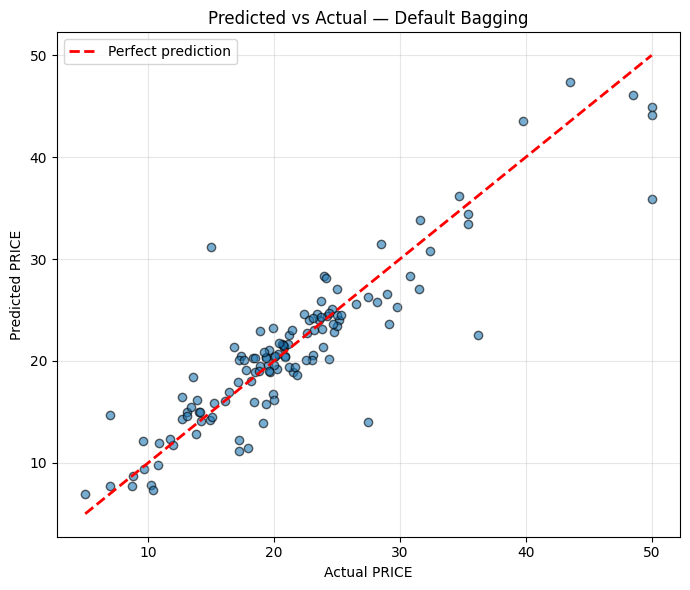

In [6]:
bag_default = BaggingRegressor(random_state=42, n_jobs=-1)
bag_default.fit(X_train, y_train)

evaluate_regression(bag_default, X_train, y_train, X_test, y_test)
plot_predicted_vs_actual(bag_default, X_test, y_test, "Default Bagging")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Bagging Params: {'bootstrap': True, 'bootstrap_features': False, 'max_features': 1.0, 'max_samples': 0.75, 'n_estimators': 50}
Best CV R²: 0.8241
──────────────────────────────────────────────────────────────────────
 Regression Metrics: Training Data
──────────────────────────────────────────────────────────────────────
  R²    : 0.9618
  MAE   : 1.2167
  MSE   : 3.3905
  RMSE  : 1.8413

──────────────────────────────────────────────────────────────────────
 Regression Metrics: Test Data
──────────────────────────────────────────────────────────────────────
  R²    : 0.8224
  MAE   : 2.2254
  MSE   : 12.4347
  RMSE  : 3.5263



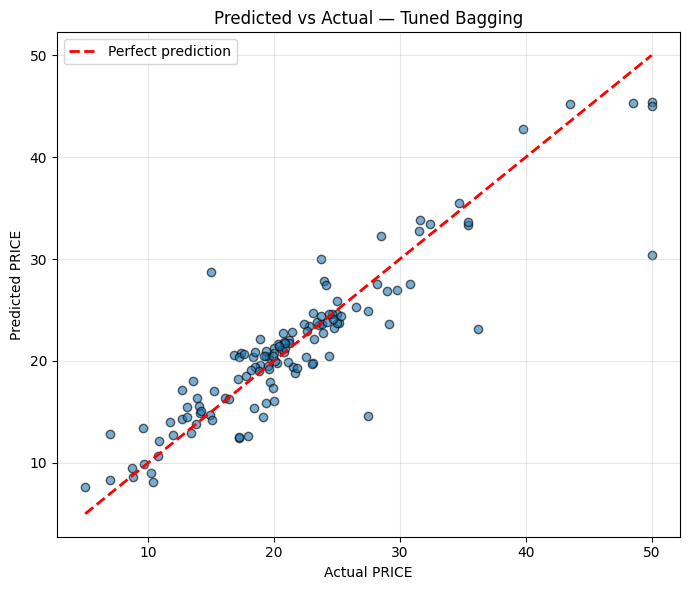

In [7]:
bag_grid = {
    'n_estimators':      [50, 100, 200, 300],
    'max_samples':       [0.5, 0.75, 1.0],
    'max_features':      [0.5, 0.75, 1.0],
    'bootstrap':         [True],
    'bootstrap_features':[False, True],
}

gs_bag = GridSearchCV(
    BaggingRegressor(random_state=42, n_jobs=1),
    bag_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
gs_bag.fit(X_train, y_train)

print(f"\nBest Bagging Params: {gs_bag.best_params_}")
print(f"Best CV R²: {gs_bag.best_score_:.4f}")

best_bag = gs_bag.best_estimator_
evaluate_regression(best_bag, X_train, y_train, X_test, y_test)
plot_predicted_vs_actual(best_bag, X_test, y_test, "Tuned Bagging")

──────────────────────────────────────────────────────────────────────
 Regression Metrics: Training Data
──────────────────────────────────────────────────────────────────────
  R²    : 0.9771
  MAE   : 0.9535
  MSE   : 2.0278
  RMSE  : 1.4240

──────────────────────────────────────────────────────────────────────
 Regression Metrics: Test Data
──────────────────────────────────────────────────────────────────────
  R²    : 0.8339
  MAE   : 2.2079
  MSE   : 11.6348
  RMSE  : 3.4110



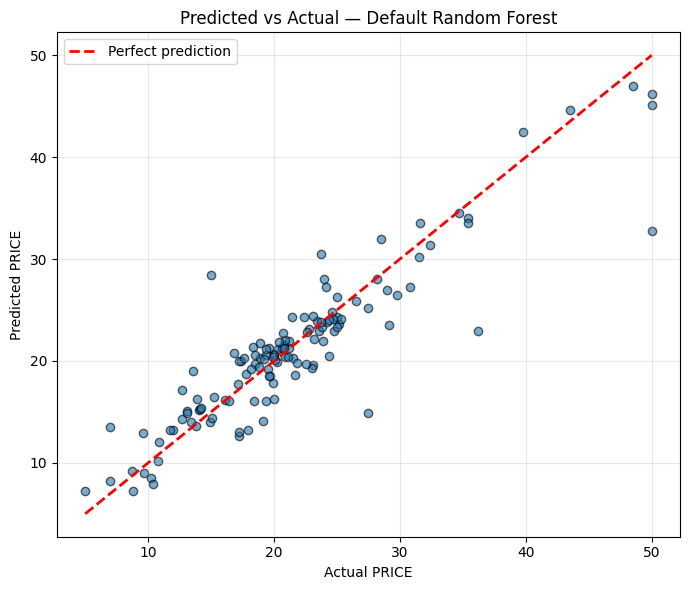

In [8]:
rf_default = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)
evaluate_regression(rf_default, X_train, y_train, X_test, y_test)
plot_predicted_vs_actual(rf_default, X_test, y_test, "Default Random Forest")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best RF Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV R²: 0.8369
──────────────────────────────────────────────────────────────────────
 Regression Metrics: Training Data
──────────────────────────────────────────────────────────────────────
  R²    : 0.9796
  MAE   : 0.8994
  MSE   : 1.8120
  RMSE  : 1.3461

──────────────────────────────────────────────────────────────────────
 Regression Metrics: Test Data
──────────────────────────────────────────────────────────────────────
  R²    : 0.8353
  MAE   : 2.0548
  MSE   : 11.5347
  RMSE  : 3.3963



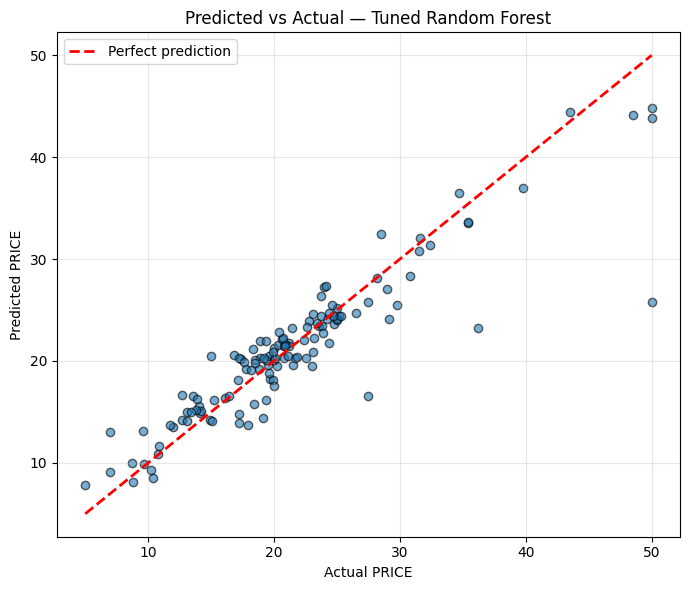

In [9]:
rf_grid = {
    'n_estimators':      [100, 200, 400],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 1.0],
}

gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    rf_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
gs_rf.fit(X_train, y_train)

print(f"\nBest RF Params: {gs_rf.best_params_}")
print(f"Best CV R²: {gs_rf.best_score_:.4f}")

best_rf = gs_rf.best_estimator_
evaluate_regression(best_rf, X_train, y_train, X_test, y_test)
plot_predicted_vs_actual(best_rf, X_test, y_test, "Tuned Random Forest")

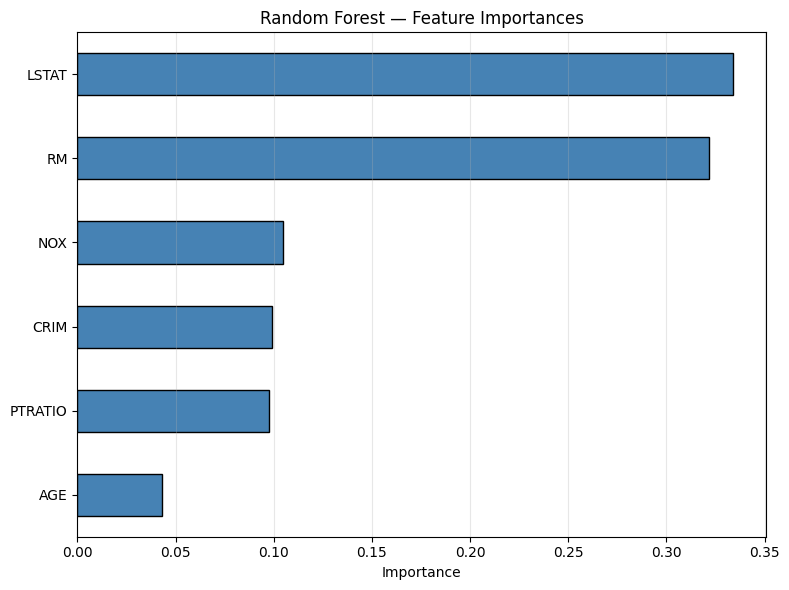

In [10]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set(xlabel='Importance', title='Random Forest — Feature Importances')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
def collect_metrics(model, name):
    y_test_pred = model.predict(X_test)
    return {
        'Model': name,
        'R²':    r2_score(y_test, y_test_pred),
        'MAE':   mean_absolute_error(y_test, y_test_pred),
        'MSE':   mean_squared_error(y_test, y_test_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_test, y_test_pred)),
    }

comparison = pd.DataFrame([
    collect_metrics(bag_default, 'Bagging (default)'),
    collect_metrics(best_bag,    'Bagging (tuned)'),
    collect_metrics(rf_default,  'Random Forest (default)'),
    collect_metrics(best_rf,     'Random Forest (tuned)'),
]).set_index('Model').round(4)

print("\n" + "═" * 40)
print(" FINAL MODEL COMPARISON (Test Set)")
print("═" * 70)
print(comparison)

best_model_name = comparison['R²'].idxmax()
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   R²:   {comparison.loc[best_model_name, 'R²']:.4f}")
print(f"   RMSE: {comparison.loc[best_model_name, 'RMSE']:.4f}")
print(f"   MAE:  {comparison.loc[best_model_name, 'MAE']:.4f}")


════════════════════════════════════════
 FINAL MODEL COMPARISON (Test Set)
══════════════════════════════════════════════════════════════════════
                             R²     MAE      MSE    RMSE
Model                                                   
Bagging (default)        0.8204  2.3155  12.5754  3.5462
Bagging (tuned)          0.8224  2.2254  12.4347  3.5263
Random Forest (default)  0.8339  2.2079  11.6348  3.4110
Random Forest (tuned)    0.8353  2.0548  11.5347  3.3963

🏆 Best Model: Random Forest (tuned)
   R²:   0.8353
   RMSE: 3.3963
   MAE:  2.0548


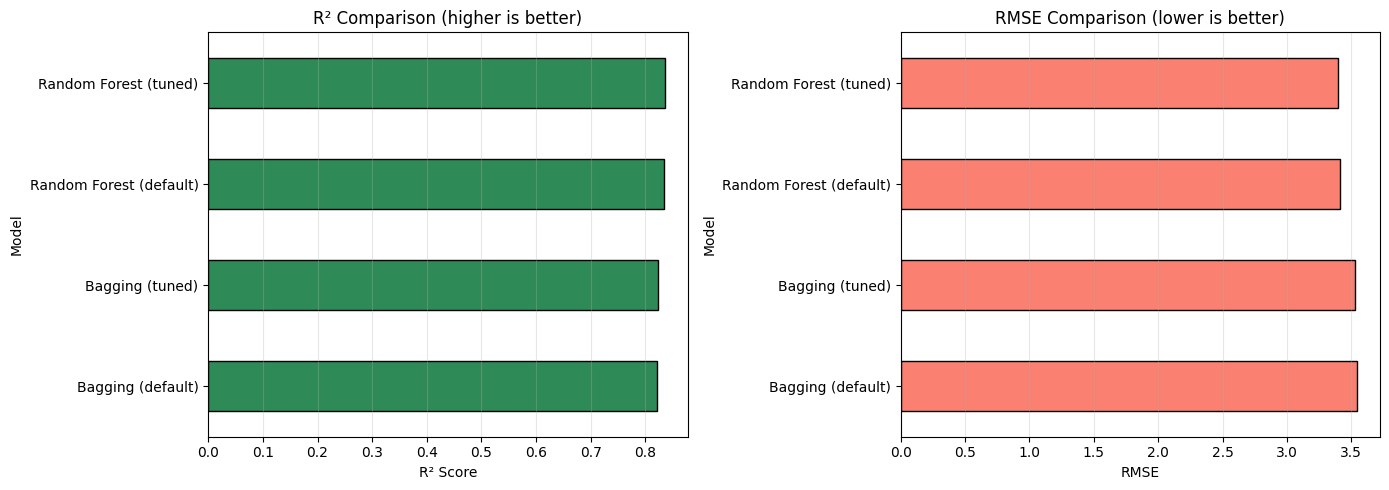

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison['R²'].plot(kind='barh', ax=axes[0], color='seagreen', edgecolor='black')
axes[0].set(xlabel='R² Score', title='R² Comparison (higher is better)')
axes[0].grid(axis='x', alpha=0.3)

comparison['RMSE'].plot(kind='barh', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set(xlabel='RMSE', title='RMSE Comparison (lower is better)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()